# 03: Training GNN Model with torch-molecule

This notebook trains a GNN-based model using torch-molecule for toxicity prediction.

Based on official torch-molecule documentation: https://liugangcode.github.io/torch-molecule/example.html

## Objectives

1. Load and prepare data for torch-molecule
2. Train torch-molecule GNN model (BFGNN) with hyperparameter optimization
3. Evaluate model performance
4. Compare with baseline MLP model


In [1]:
# Setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, average_precision_score
import matplotlib.pyplot as plt

from src.data import load_clintox
from src.utils import set_seed, get_default_config

# Set seed for reproducibility
set_seed(42)
config = get_default_config()

print("✓ Imports successful")

✓ Imports successful


## Load Data

Load the ClinTox dataset. torch-molecule models accept SMILES strings directly.


In [2]:
# Load dataset
cache_dir = project_root / "data"
train_df, val_df, test_df = load_clintox(cache_dir=str(cache_dir), split_type="scaffold", seed=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Class distribution - Train: Toxic={train_df['CT_TOX'].sum()}, Non-toxic={len(train_df) - train_df['CT_TOX'].sum()}")

# Prepare SMILES strings and labels as lists/arrays
# torch-molecule expects SMILES as list of strings
X_train = train_df['smiles'].tolist()
y_train = train_df['CT_TOX'].values
X_val = val_df['smiles'].tolist()
y_val = val_df['CT_TOX'].values
X_test = test_df['smiles'].tolist()
y_test = test_df['CT_TOX'].values

# Convert labels to list of lists format (for compatibility)
# For binary classification, each label should be [0] or [1]
y_train_list = [[int(y)] for y in y_train]
y_val_list = [[int(y)] for y in y_val]
y_test_list = [[int(y)] for y in y_test]

print(f"✓ Data prepared for torch-molecule")
print(f"  X_train: {len(X_train)} SMILES strings")
print(f"  y_train: {len(y_train_list)} labels (format: list of lists)")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'
'split' is deprecated.  Use 'splitter' instead.


Train: 1184, Val: 148, Test: 148
Class distribution - Train: Toxic=95.0, Non-toxic=1089.0
✓ Data prepared for torch-molecule
  X_train: 1184 SMILES strings
  y_train: 1184 labels (format: list of lists)


## Create torch-molecule Model

Initialize BFGNNMolecularPredictor according to the official documentation.
For binary classification, we set `task_type='classification'` and `num_task=1`.


In [3]:
# Import torch-molecule components
try:
    from torch_molecule import BFGNNMolecularPredictor
    from torch_molecule.utils.search import ParameterType, ParameterSpec
    print("✓ torch-molecule imported successfully")
except ImportError as e:
    print(f"⚠ Error importing torch-molecule: {e}")
    print("Install with: pip install torch-molecule torch-geometric torch-scatter")
    raise

# Initialize model with proper parameters for binary classification
# Based on documentation: https://liugangcode.github.io/torch-molecule/example.html
try:
    model = BFGNNMolecularPredictor(
        num_task=1,  # Single binary classification task
        task_type="classification",  # Binary classification
        batch_size=32,  # Batch size for training
        epochs=50,  # Number of training epochs
        evaluate_criterion='roc_auc',  # Evaluation metric
        evaluate_higher_better=True,  # Higher ROC-AUC is better
        verbose='progress_bar'  # Show progress bar during training
    )
    print(f"✓ BFGNNMolecularPredictor created successfully")
    print(f"  Model type: {type(model)}")
except Exception as e:
    print(f"⚠ Error creating model: {e}")
    print("Trying with minimal parameters...")
    try:
        # Fallback: try with fewer parameters
        model = BFGNNMolecularPredictor(
            num_task=1,
            task_type="classification",
            batch_size=32,
            epochs=50,
            verbose='progress_bar'
        )
        print("✓ Model created with minimal parameters")
    except Exception as e2:
        print(f"⚠ Error with minimal parameters: {e2}")
        model = None
        raise

✓ torch-molecule imported successfully
✓ BFGNNMolecularPredictor created successfully
  Model type: <class 'torch_molecule.predictor.bfgnn.modeling_bfgnn.BFGNNMolecularPredictor'>


## Define Hyperparameter Search Space

According to the documentation, we can define a search space for hyperparameter optimization.
We'll use `autofit()` which automatically searches for the best hyperparameters.


In [4]:
# Define hyperparameter search space
# Based on documentation example
search_parameters = {
    "gnn_type": ParameterSpec(ParameterType.CATEGORICAL, ["gin-virtual", "gcn-virtual", "gin", "gcn"]),
    "norm_layer": ParameterSpec(ParameterType.CATEGORICAL, ["batch_norm", "layer_norm"]),
    "graph_pooling": ParameterSpec(ParameterType.CATEGORICAL, ["mean", "sum", "max"]),
    "augmented_feature": ParameterSpec(ParameterType.CATEGORICAL, ["maccs,morgan", "maccs", "morgan", None]),
    "num_layer": ParameterSpec(ParameterType.INTEGER, (2, 5)),
    "hidden_size": ParameterSpec(ParameterType.INTEGER, (64, 256)),
    "drop_ratio": ParameterSpec(ParameterType.FLOAT, (0.0, 0.5)),
    "learning_rate": ParameterSpec(ParameterType.LOG_FLOAT, (1e-5, 1e-2)),
    "weight_decay": ParameterSpec(ParameterType.LOG_FLOAT, (1e-10, 1e-3)),
}

print("✓ Hyperparameter search space defined")
print(f"  Number of hyperparameters: {len(search_parameters)}")

✓ Hyperparameter search space defined
  Number of hyperparameters: 9


## Train Model with Hyperparameter Optimization

Use `autofit()` method as shown in the official documentation.
This will automatically search for the best hyperparameters.


In [5]:
# Train model with hyperparameter optimization
if model is not None:
    print("=" * 70)
    print("Training torch-molecule model with hyperparameter optimization")
    print("=" * 70)
    print(f"Training data: {len(X_train)} samples")
    print(f"Validation data: {len(X_val)} samples")
    print(f"Class distribution - Toxic: {y_train.sum()}, Non-toxic: {len(y_train) - y_train.sum()}")
    print(f"Hyperparameter search trials: {config.get('torch_molecule', {}).get('n_trials', 20)}")
    print()
    
    try:
        # Use autofit() for hyperparameter optimization
        # Based on documentation example
        n_trials = config.get('torch_molecule', {}).get('n_trials', 20)  # Number of hyperparameter search trials
        
        model.autofit(
            X_train=X_train,  # List of SMILES strings
            y_train=y_train_list,  # List of lists: [[0], [1], ...]
            X_val=X_val,
            y_val=y_val_list,
            n_trials=n_trials,
            search_parameters=search_parameters
        )
        
        print("\n✓ Model training completed!")
        
    except Exception as e:
        print(f"\n⚠ Error during autofit(): {e}")
        print("Trying fit() without hyperparameter search...")
        import traceback
        traceback.print_exc()
        
        # Fallback to regular fit() if autofit() fails
        try:
            model.fit(
                X_train=X_train,
                y_train=y_train_list,
                X_val=X_val,
                y_val=y_val_list
            )
            print("✓ Model trained with fit() (no hyperparameter search)")
        except Exception as e2:
            print(f"⚠ Error with fit(): {e2}")
            raise
else:
    print("⚠ Model not available for training")

[I 2025-11-29 21:17:28,624] A new study created in memory with name: BFGNNMolecularPredictor_optimization


Training torch-molecule model with hyperparameter optimization
Training data: 1184 samples
Validation data: 148 samples
Class distribution - Toxic: 95.0, Non-toxic: 1089.0
Hyperparameter search trials: 20


Parameter Search Configuration:
--------------------------------------------------

 Parameters being searched:
  • augmented_feature: ['maccs,morgan', 'maccs', 'morgan', None]
  • drop_ratio: [0.0, 0.5]
  • gnn_type: ['gin-virtual', 'gcn-virtual', 'gin', 'gcn']
  • graph_pooling: ['mean', 'sum', 'max']
  • hidden_size: [64, 256]
  • learning_rate: [1e-05, 0.01]
  • norm_layer: ['batch_norm', 'layer_norm']
  • num_layer: [2, 5]
  • weight_decay: [1e-10, 0.001]

 Fixed parameters (not being searched):
  • batch_size: 32
  • device: cpu
  • epochs: 50
  • evaluate_criterion: <function roc_auc_score at 0x33be4a5c0>
  • evaluate_higher_better: True
  • evaluate_name: roc_auc
  • fitting_epoch: 0
  • fitting_loss: []
  • grad_clip_value: None
  • l1_penalty: 0.001
  • loss_criterion: BCE

  0%|          | 0/20 [00:00<?, ?it/s]

Predicting: 100%|██████████| 5/5 [00:00<00:00, 82.62it/s]


Trial 0: roc_auc = 0.9919 (better than best = 0.9919)
Current parameters:
  gnn_type: gcn-virtual
  norm_layer: layer_norm
  graph_pooling: max
  augmented_feature: None
  num_layer: 5
  hidden_size: 124
  drop_ratio: 0.07446658317716803
  learning_rate: 0.0026673769065900872
  weight_decay: 4.681205137187262e-10
[I 2025-11-29 21:18:20,642] Trial 0 finished with value: -0.9918946301925025 and parameters: {'gnn_type': 'gcn-virtual', 'norm_layer': 'layer_norm', 'graph_pooling': 'max', 'augmented_feature': None, 'num_layer': 5, 'hidden_size': 124, 'drop_ratio': 0.07446658317716803, 'learning_rate': 0.0026673769065900872, 'weight_decay': 4.681205137187262e-10}. Best is trial 0 with value: -0.9918946301925025.


...

Trial 18: roc_auc = 0.9737 (worse than best = 0.9919)
Current parameters:
  gnn_type: gcn-virtual
  norm_layer: batch_norm
  graph_pooling: max
  augmented_feature: ['maccs', 'morgan']
  num_layer: 4
  hidden_size: 139
  drop_ratio: 0.16989269651022093
  learning_rate: 0.00022718176718955675
  weight_decay: 6.508567794923634e-09
[I 2025-11-29 21:35:38,431] Trial 18 finished with value: -0.9736575481256332 and parameters: {'gnn_type': 'gcn-virtual', 'norm_layer': 'batch_norm', 'graph_pooling': 'max', 'augmented_feature': 'maccs,morgan', 'num_layer': 4, 'hidden_size': 139, 'drop_ratio': 0.16989269651022093, 'learning_rate': 0.00022718176718955675, 'weight_decay': 6.508567794923634e-09}. Best is trial 0 with value: -0.9918946301925025.


Predicting: 100%|██████████| 5/5 [00:00<00:00, 156.08it/s]


Trial 19: roc_auc = 0.8004 (worse than best = 0.9919)
Current parameters:
  gnn_type: gcn
  norm_layer: layer_norm
  graph_pooling: sum
  augmented_feature: None
  num_layer: 3
  hidden_size: 103
  drop_ratio: 0.05790182647699785
  learning_rate: 0.001027508475253276
  weight_decay: 4.953071992646012e-10
[I 2025-11-29 21:36:12,166] Trial 19 finished with value: -0.8004052684903749 and parameters: {'gnn_type': 'gcn', 'norm_layer': 'layer_norm', 'graph_pooling': 'sum', 'augmented_feature': None, 'num_layer': 3, 'hidden_size': 103, 'drop_ratio': 0.05790182647699785, 'learning_rate': 0.001027508475253276, 'weight_decay': 4.953071992646012e-10}. Best is trial 0 with value: -0.9918946301925025.

Optimization completed successfully:
Best roc_auc: 0.9919


Predicting: 100%|██████████| 5/5 [00:00<00:00, 70.57it/s]

post score is:  0.9918946301925025

Best parameters:
  gnn_type: gcn-virtual (type: categorical)
  norm_layer: layer_norm (type: categorical)
  graph_pooling: max (type: categorical)
  augmented_feature: None (type: categorical)
  num_layer: 5 (type: integer)
  hidden_size: 124 (type: integer)
  drop_ratio: 0.07446658317716803 (type: float)
  learning_rate: 0.0026673769065900872 (type: log_float)
  weight_decay: 4.681205137187262e-10 (type: log_float)

Optimization statistics:
  Number of completed trials: 20
  Number of pruned trials: 0
  Number of failed trials: 0

✓ Model training completed!


## Evaluate on Validation Set

Evaluate the trained model on the validation set.


In [6]:
# Evaluate on validation set
if model is not None:
    print("=" * 70)
    print("Validation Set Evaluation")
    print("=" * 70)
    
    try:
        # Get predictions from model
        # According to documentation, predict() returns a dictionary
        val_predictions = model.predict(X_val)
        
        # Extract predictions from dictionary
        if isinstance(val_predictions, dict):
            if 'prediction' in val_predictions:
                y_val_pred = np.array(val_predictions['prediction']).flatten()
            elif 'predictions' in val_predictions:
                y_val_pred = np.array(val_predictions['predictions']).flatten()
            else:
                # Try to get first value
                y_val_pred = np.array(list(val_predictions.values())[0]).flatten()
        else:
            y_val_pred = np.array(val_predictions).flatten()
        
        # Handle logits vs probabilities
        # If values are outside [0,1], apply sigmoid
        if y_val_pred.min() < 0 or y_val_pred.max() > 1:
            from scipy.special import expit
            y_val_proba = expit(y_val_pred)
        else:
            y_val_proba = y_val_pred
        
        # Convert to binary predictions
        y_val_pred_binary = (y_val_proba > 0.5).astype(int)
        
        # Calculate metrics
        val_metrics = {
            'auc_roc': roc_auc_score(y_val, y_val_proba),
            'accuracy': accuracy_score(y_val, y_val_pred_binary),
            'f1': f1_score(y_val, y_val_pred_binary, zero_division=0),
            'pr_auc': average_precision_score(y_val, y_val_proba)
        }
        
        print(f"\nValidation Metrics:")
        print(f"  AUC-ROC: {val_metrics['auc_roc']:.4f}")
        print(f"  Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"  F1 Score: {val_metrics['f1']:.4f}")
        print(f"  PR-AUC: {val_metrics['pr_auc']:.4f}")
        print(f"\nProbability Statistics:")
        print(f"  Min: {y_val_proba.min():.4f}, Max: {y_val_proba.max():.4f}")
        print(f"  Mean: {y_val_proba.mean():.4f}, Median: {np.median(y_val_proba):.4f}")
        print(f"  Positive predictions: {y_val_pred_binary.sum()}/{len(y_val_pred_binary)}")
        
    except Exception as e:
        print(f"⚠ Error during validation: {e}")
        import traceback
        traceback.print_exc()
        val_metrics = None
else:
    val_metrics = None

Validation Set Evaluation


Predicting: 100%|██████████| 5/5 [00:00<00:00, 63.89it/s]


Validation Metrics:
  AUC-ROC: 0.9919
  Accuracy: 0.9527
  F1 Score: 0.0000
  PR-AUC: 0.7968

Probability Statistics:
  Min: 0.0001, Max: 0.3110
  Mean: 0.0187, Median: 0.0009
  Positive predictions: 0/148


## Evaluate on Test Set

Evaluate the trained model on the test set.


In [10]:
# Evaluate on test set
if model is not None:
    print("=" * 70)
    print("Test Set Evaluation")
    print("=" * 70)
    
    try:
        # Get predictions
        test_predictions = model.predict(X_test)
        
        # Extract predictions from dictionary
        if isinstance(test_predictions, dict):
            if 'prediction' in test_predictions:
                y_test_pred = np.array(test_predictions['prediction']).flatten()
            elif 'predictions' in test_predictions:
                y_test_pred = np.array(test_predictions['predictions']).flatten()
            else:
                y_test_pred = np.array(list(test_predictions.values())[0]).flatten()
        else:
            y_test_pred = np.array(test_predictions).flatten()
        
        # Convert logits to probabilities if needed
        if y_test_pred.min() < 0 or y_test_pred.max() > 1:
            from scipy.special import expit
            y_test_proba = expit(y_test_pred)
        else:
            y_test_proba = y_test_pred
        
        # Convert to binary predictions
        y_test_pred_binary = (y_test_proba > 0.5).astype(int)
        
        # Calculate metrics
        # Note: AUPRC (Area Under Precision-Recall Curve) = average_precision_score
        auprc = average_precision_score(y_test, y_test_proba)
        test_metrics = {
            'auc_roc': roc_auc_score(y_test, y_test_proba),
            'accuracy': accuracy_score(y_test, y_test_pred_binary),
            'f1': f1_score(y_test, y_test_pred_binary, zero_division=0),
            'pr_auc': auprc,
            'auprc': auprc  # AUPRC is the same as PR-AUC (average precision)
        }
        
        print(f"\nTest Set Metrics:")
        print(f"  AUC-ROC: {test_metrics['auc_roc']:.4f}")
        print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  F1 Score: {test_metrics['f1']:.4f}")
        print(f"  PR-AUC: {test_metrics['pr_auc']:.4f}")
        print(f"  AUPRC: {test_metrics['auprc']:.4f}")
        print(f"\nProbability Statistics:")
        print(f"  Min: {y_test_proba.min():.4f}, Max: {y_test_proba.max():.4f}")
        print(f"  Mean: {y_test_proba.mean():.4f}, Median: {np.median(y_test_proba):.4f}")
        print(f"  Positive predictions: {y_test_pred_binary.sum()}/{len(y_test_pred_binary)}")
        print(f"  Positive ground truth: {y_test.sum()}/{len(y_test)}")
        
    except Exception as e:
        print(f"⚠ Error during test evaluation: {e}")
        import traceback
        traceback.print_exc()
        test_metrics = None
else:
    test_metrics = None

Test Set Evaluation


Predicting: 100%|██████████| 5/5 [00:00<00:00, 93.70it/s]


Test Set Metrics:
  AUC-ROC: 0.9188
  Accuracy: 0.9392
  F1 Score: 0.1818
  PR-AUC: 0.6164
  AUPRC: 0.6164

Probability Statistics:
  Min: 0.0001, Max: 0.7931
  Mean: 0.0369, Median: 0.0021
  Positive predictions: 1/148
  Positive ground truth: 10.0/148


## Compare with Baseline Model

Compare torch-molecule GNN model performance with the baseline MLP model.



Model Comparison
                 Model  AUC-ROC  Accuracy       F1    AUPRC
          Baseline MLP 0.716700  0.939200 0.470600 0.449700
torch-molecule (BFGNN) 0.918841  0.939189 0.181818 0.616369

✓ Comparison figure saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/03_model_comparison.png


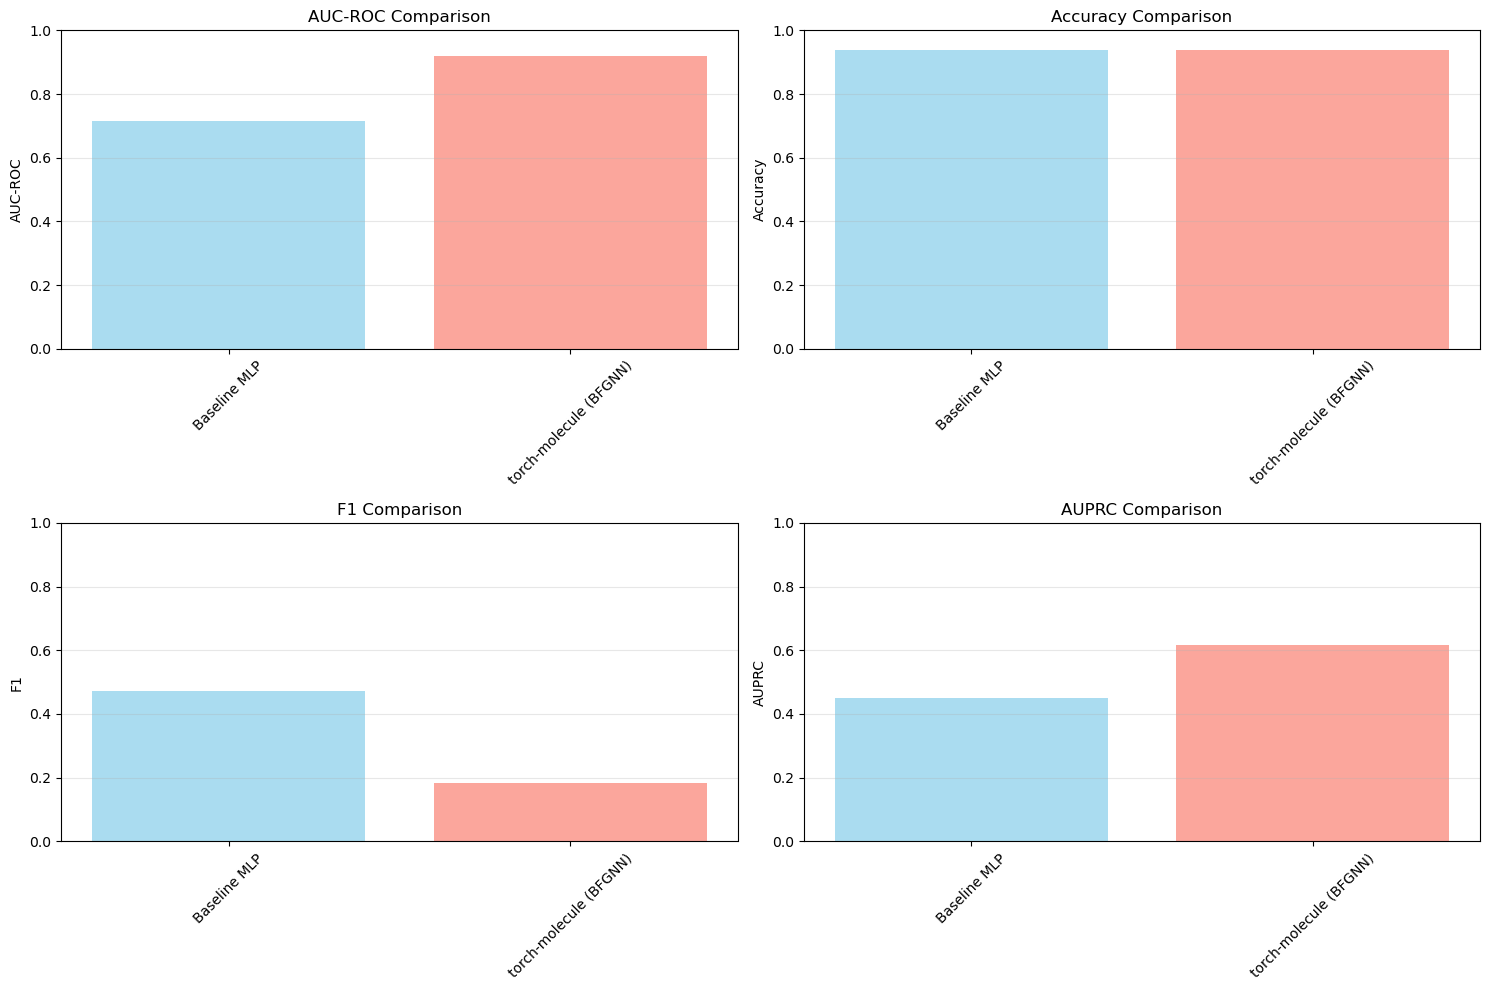

In [11]:
# Load baseline metrics if available
baseline_metrics_path = project_root / "models" / "baseline_metrics.txt"
comparison_data = []

if baseline_metrics_path.exists():
    from src.utils import load_metrics
    baseline_metrics = load_metrics(baseline_metrics_path)
    # Get AUPRC from baseline metrics (check both 'auprc' and 'pr_auc' keys)
    baseline_auprc = baseline_metrics.get('auprc', baseline_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'Baseline MLP',
        'AUC-ROC': baseline_metrics.get('auc_roc', 'N/A'),
        'Accuracy': baseline_metrics.get('accuracy', 'N/A'),
        'F1': baseline_metrics.get('f1', 'N/A'),
        'AUPRC': baseline_auprc
    })

if test_metrics is not None:
    # Get AUPRC from test metrics (check both 'auprc' and 'pr_auc' keys)
    test_auprc = test_metrics.get('auprc', test_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': f"torch-molecule (BFGNN)",
        'AUC-ROC': test_metrics.get('auc_roc', 'N/A'),
        'Accuracy': test_metrics.get('accuracy', 'N/A'),
        'F1': test_metrics.get('f1', 'N/A'),
        'AUPRC': test_auprc
    })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + "=" * 70)
    print("Model Comparison")
    print("=" * 70)
    print(comparison_df.to_string(index=False))
    
    # Visualize comparison
    if len(comparison_data) > 1:
        # Update to 2x2 layout to include AUPRC
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()  # Flatten to 1D array for easier indexing
        metrics_to_plot = ['AUC-ROC', 'Accuracy', 'F1', 'AUPRC']
        
        for idx, metric in enumerate(metrics_to_plot):
            values = []
            labels = []
            for row in comparison_data:
                val = row[metric]
                if val != 'N/A' and isinstance(val, (int, float)):
                    values.append(val)
                    labels.append(row['Model'])
            
            if values:
                axes[idx].bar(labels, values, alpha=0.7, color=['skyblue', 'salmon'])
                axes[idx].set_ylabel(metric)
                axes[idx].set_title(f'{metric} Comparison')
                axes[idx].grid(axis='y', alpha=0.3)
                axes[idx].set_ylim([0, 1])
                axes[idx].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        
        # Save figure
        figures_dir = project_root / "output" / "figures"
        figures_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(figures_dir / "03_model_comparison.png", dpi=300, bbox_inches='tight')
        print(f"\n✓ Comparison figure saved to: {figures_dir / '03_model_comparison.png'}")
        
        plt.show()
else:
    print("No comparison data available")

## Save Model and Results

Save the trained torch-molecule model and evaluation metrics.


In [9]:
# Save model and metrics if available
if model is not None and test_metrics is not None:
    models_dir = project_root / "models"
    models_dir.mkdir(exist_ok=True)
    
    # Save model using torch-molecule's save method if available
    try:
        # Try using Hugging Face Hub integration if available
        if hasattr(model, 'save_model'):
            model_path = models_dir / "torch_molecule_model.pt"
            model.save_model(str(model_path))
            print(f"✓ Model saved to: {model_path}")
        else:
            # Fallback to pickle
            model_path = models_dir / "torch_molecule_model.pkl"
            import pickle
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
            print(f"✓ Model saved to: {model_path} (using pickle)")
    except Exception as e:
        print(f"⚠ Could not save model: {e}")
        print("Please refer to torch-molecule documentation for model saving.")
    
    # Save metrics
    from src.utils import save_metrics
    metrics_path = models_dir / "torch_molecule_metrics.txt"
    save_metrics(test_metrics, metrics_path)
    print(f"✓ Metrics saved to: {metrics_path}")
else:
    print("Model or metrics not available for saving")

✓ Model saved to: /Users/nguyennghia/PROJECT/Torch_molecule/models/torch_molecule_model.pkl (using pickle)
✓ Metrics saved to: /Users/nguyennghia/PROJECT/Torch_molecule/models/torch_molecule_metrics.txt


## Summary

✓ torch-molecule GNN model trained with hyperparameter optimization  
✓ Model evaluated on validation and test sets  
✓ Comparison with baseline completed  

**Next Steps:**
- Proceed to `04_explainability_and_visualization.ipynb` to generate explanations and visualizations

**References:**
- torch-molecule documentation: https://liugangcode.github.io/torch-molecule/example.html
- torch-molecule GitHub: https://github.com/liugangcode/torch-molecule
